# Smadex hackathon — fatigue score over time (LightGBM + walk-forward CV)

This notebook matches the project docs in `README.md`, `data_science/README.md`, `data_science/data/README.md`, and `hackaton.md`:

- **Fact table:** `creative_daily_country_os_stats.csv` (grain: date × creative × country × OS).
- **Creative features:** `creatives.csv` (no images in v1).
- **Goal:** learn a **smooth fatigue score** in \[0, 1\] from **relative CTR erosion** vs an **expanding early-life baseline** (no fixed global threshold on raw CPA/CTR).
- **Live simulation:** features for predicting day \(t\) use only history **strictly before** \(t\) (through \(t-1\)).
- **Validation:** **walk-forward CV** on calendar time; **holdout test = last 7 calendar days** in the CSV.

**Fatigue score definition (continuous, per creative, per day):**

1. Roll up the fact table to **creative × date** (sum impressions, clicks, conversions, spend, etc.).
2. **CTR\(_d\)** = clicks / impressions (with a small denominator guard).
3. **Rolling 7d CTR** at date \(t\): ratio of sums over \[t-6, t\] (inclusive).
4. **Baseline CTR at \(t\)** = median of rolling-7d CTR on past days where `3 <= days_since_launch <= 10` and `date <= t` (expanding “post-warmup, early life” reference). If missing, fall back to median rolling CTR on all past days with `date < t`.
5. **fatigue_score\(t\)** = `1 - min(1, rolling7_ctr(t) / (baseline_ctr(t) + eps))` → **0** when CTR is at/above baseline, **→ 1** when CTR collapses toward zero.

**Model:** LightGBM regression predicting **fatigue_score(t)** from lag features + static creative metadata. **Feature importance** from gain-based split importance (and optional SHAP if installed).

In [8]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)

NOTEBOOK_DIR = Path.cwd()
DATA_DIR = (NOTEBOOK_DIR / "../data").resolve()
assert (DATA_DIR / "creative_daily_country_os_stats.csv").exists(), DATA_DIR

RANDOM_SEED = 42
LAST_N_CALENDAR_DAYS_TEST = 7
EPS = 1e-9

In [9]:
daily = pd.read_csv(
    DATA_DIR / "creative_daily_country_os_stats.csv",
    parse_dates=["date"],
)
creatives = pd.read_csv(DATA_DIR / "creatives.csv")

print("daily rows", len(daily), "date range", daily["date"].min(), daily["date"].max())
print("creatives", len(creatives))

daily rows 192315 date range 2026-01-01 00:00:00 2026-03-16 00:00:00
creatives 1080


## 1) Roll up to creative × date

We sum volume columns across country × OS. **Do not sum** `impressions_last_7d` across slices (README caveat); we recompute rolling windows ourselves on the rolled-up series.

In [10]:
def rollup_creative_day(df: pd.DataFrame) -> pd.DataFrame:
    gcols = ["creative_id", "campaign_id", "date", "days_since_launch"]
    agg = (
        df.groupby(gcols, as_index=False)
        .agg(
            impressions=("impressions", "sum"),
            viewable_impressions=("viewable_impressions", "sum"),
            clicks=("clicks", "sum"),
            conversions=("conversions", "sum"),
            spend_usd=("spend_usd", "sum"),
            revenue_usd=("revenue_usd", "sum"),
            video_completions=("video_completions", "sum"),
        )
    )
    imp = agg["impressions"].clip(lower=0)
    clk = agg["clicks"].clip(lower=0)
    conv = agg["conversions"].clip(lower=0)
    agg["ctr"] = np.where(imp > 0, clk / imp.astype(float), np.nan)
    agg["cvr"] = np.where(clk > 0, conv / clk.astype(float), np.nan)
    agg["cpa"] = np.where(conv > 0, agg["spend_usd"] / conv.astype(float), np.nan)
    agg["roas"] = np.where(agg["spend_usd"] > 0, agg["revenue_usd"] / agg["spend_usd"], np.nan)
    agg["ipm"] = np.where(imp > 0, 1000.0 * conv / imp.astype(float), np.nan)
    return agg.sort_values(["creative_id", "date"]).reset_index(drop=True)


cd = rollup_creative_day(daily)
cd.head()

,creative_id,campaign_id,date,days_since_launch,impressions,viewable_impressions,clicks,conversions,spend_usd,revenue_usd,video_completions,ctr,cvr,cpa,roas,ipm
0,500000,20000,2026-01-19,0,940460,769746,10626,2156,5917.42,11713.79,0,0.011299,0.202899,2.744629,1.979543,2.292495
1,500000,20000,2026-01-20,1,450862,376573,4302,905,2669.38,4990.81,0,0.009542,0.210367,2.949591,1.869651,2.007266
2,500000,20000,2026-01-21,2,455904,381052,3924,721,2804.97,4024.43,0,0.008607,0.183741,3.890388,1.434750,1.581473
3,500000,20000,2026-01-22,3,347661,283529,2831,550,2202.00,2832.93,0,0.008143,0.194278,4.003636,1.286526,1.582001
4,500000,20000,2026-01-23,4,380006,303292,2475,467,2332.58,2374.40,0,0.006513,0.188687,4.994818,1.017929,1.228928


## 2) Rolling 7d KPIs + smooth fatigue label (causal / live-safe)

For each calendar date \(t\), **baseline_ctr(t)** only uses **history through t** on the early-life window (DSL 3–10). The **target** fatigue_score(t) uses **rolling7_ctr(t)** including day \(t\).  
**Model inputs** for predicting that target will be built only from **dates < t** in the next section.

In [11]:
def add_rollings_and_fatigue(panel: pd.DataFrame) -> pd.DataFrame:
    out = []
    for cid, g in panel.groupby("creative_id", sort=False):
        g = g.sort_values("date").copy()
        idx = g.index
        g["r7_impressions"] = g["impressions"].rolling(7, min_periods=3).sum()
        g["r7_clicks"] = g["clicks"].rolling(7, min_periods=3).sum()
        g["r7_conversions"] = g["conversions"].rolling(7, min_periods=3).sum()
        g["r7_spend"] = g["spend_usd"].rolling(7, min_periods=3).sum()
        g["rolling7_ctr"] = np.where(
            g["r7_impressions"] > 0, g["r7_clicks"] / g["r7_impressions"].astype(float), np.nan
        )
        g["rolling7_cpa"] = np.where(
            g["r7_conversions"] > 0,
            g["r7_spend"] / g["r7_conversions"].astype(float),
            np.nan,
        )
        g["rolling7_cvr"] = np.where(
            g["r7_clicks"] > 0,
            g["r7_conversions"] / g["r7_clicks"].astype(float),
            np.nan,
        )

        baseline = []
        for i in range(len(g)):
            past = g.iloc[: i + 1]
            mask = (past["days_since_launch"] >= 3) & (past["days_since_launch"] <= 10)
            vals = past.loc[mask, "rolling7_ctr"].dropna()
            if len(vals) >= 2:
                baseline.append(float(vals.median()))
            else:
                fallback = past["rolling7_ctr"].iloc[:-1].dropna() if i > 0 else past["rolling7_ctr"].dropna()
                baseline.append(float(fallback.median()) if len(fallback) else np.nan)
        g["baseline_ctr"] = baseline

        ratio = g["rolling7_ctr"] / (g["baseline_ctr"] + EPS)
        g["fatigue_score"] = (1.0 - np.minimum(1.0, ratio)).clip(0.0, 1.0)
        out.append(g)
    return pd.concat(out, ignore_index=True)


cd = add_rollings_and_fatigue(cd)
cd[["creative_id", "date", "days_since_launch", "rolling7_ctr", "baseline_ctr", "fatigue_score"]].head(12)

,creative_id,date,days_since_launch,rolling7_ctr,baseline_ctr,fatigue_score
0,500000,2026-01-19,0,NaN,NaN,NaN
1,500000,2026-01-20,1,NaN,NaN,NaN
2,500000,2026-01-21,2,0.010206,NaN,NaN
3,500000,2026-01-22,3,0.009879,0.010206,0.032012
4,500000,2026-01-23,4,0.009382,0.009631,0.025790
5,500000,2026-01-24,5,0.008887,0.009382,0.052802
6,500000,2026-01-25,6,0.008469,0.009134,0.072863
7,500000,2026-01-26,7,0.007024,0.008887,0.209652
8,500000,2026-01-27,8,0.006211,0.008678,0.284217
9,500000,2026-01-28,9,0.005467,0.008469,0.354489


## 3) Build training rows: **predict fatigue_score(t)** from **history before t**

We shift the panel by one day so each row’s feature window ends at **t-1**, while **y = fatigue_score** at **t**.

In [12]:
def _lin_slope(y: np.ndarray) -> float:
    y = y.astype(float)
    m = np.isfinite(y)
    if m.sum() < 2:
        return 0.0
    x = np.arange(len(y), dtype=float)[m]
    yy = y[m]
    x = x - x.mean()
    denom = (x**2).sum()
    if denom <= 0:
        return 0.0
    return float((x * (yy - yy.mean())).sum() / denom)


def build_shifted_ml_table(panel: pd.DataFrame, creatives_meta: pd.DataFrame) -> pd.DataFrame:
    rows = []
    feat_cols_numeric = [
        "hist_r7_ctr_mean",
        "hist_r7_ctr_std",
        "hist_r7_ctr_slope",
        "hist_ctr_mean",
        "hist_ctr_slope",
        "hist_r7_cpa_mean",
        "hist_r7_cpa_slope",
        "hist_r7_cvr_mean",
        "hist_impressions_sum",
        "hist_spend_sum",
        "hist_clicks_sum",
        "hist_conversions_sum",
        "days_since_launch_lag1",
        "log1p_hist_impressions",
        "log1p_hist_spend",
    ]
    for cid, g in panel.groupby("creative_id", sort=False):
        g = g.sort_values("date").reset_index(drop=True)
        if len(g) < 10:
            continue
        meta = creatives_meta.loc[creatives_meta["creative_id"] == cid].iloc[0]
        for i in range(1, len(g)):
            past = g.iloc[:i]
            if len(past) < 7:
                continue
            win = past.iloc[-7:]
            y = float(g.iloc[i]["fatigue_score"])
            if not np.isfinite(y):
                continue
            row = {
                "creative_id": cid,
                "campaign_id": int(g.iloc[i]["campaign_id"]),
                "pred_date": g.iloc[i]["date"],
                "y_fatigue_score": y,
                "hist_r7_ctr_mean": float(win["rolling7_ctr"].mean()),
                "hist_r7_ctr_std": float(win["rolling7_ctr"].std(ddof=0) or 0.0),
                "hist_r7_ctr_slope": _lin_slope(win["rolling7_ctr"].to_numpy()),
                "hist_ctr_mean": float(win["ctr"].mean()),
                "hist_ctr_slope": _lin_slope(win["ctr"].fillna(0.0).to_numpy()),
                "hist_r7_cpa_mean": float(np.nanmean(win["rolling7_cpa"].to_numpy())),
                "hist_r7_cpa_slope": _lin_slope(np.nan_to_num(win["rolling7_cpa"].to_numpy(), nan=np.nanmedian(win["rolling7_cpa"]))),
                "hist_r7_cvr_mean": float(np.nanmean(win["rolling7_cvr"].to_numpy())),
                "hist_impressions_sum": float(win["impressions"].sum()),
                "hist_spend_sum": float(win["spend_usd"].sum()),
                "hist_clicks_sum": float(win["clicks"].sum()),
                "hist_conversions_sum": float(win["conversions"].sum()),
                "days_since_launch_lag1": float(past.iloc[-1]["days_since_launch"]),
                "log1p_hist_impressions": float(np.log1p(win["impressions"].sum())),
                "log1p_hist_spend": float(np.log1p(win["spend_usd"].sum())),
                "format": meta["format"],
                "vertical": meta["vertical"],
                "language": meta["language"],
                "theme": meta["theme"],
                "hook_type": meta["hook_type"],
                "dominant_color": meta["dominant_color"],
                "emotional_tone": meta["emotional_tone"],
                "motion_score": float(meta["motion_score"]),
                "text_density": float(meta["text_density"]),
                "novelty_score": float(meta["novelty_score"]),
                "clutter_score": float(meta["clutter_score"]),
                "readability_score": float(meta["readability_score"]),
                "brand_visibility_score": float(meta["brand_visibility_score"]),
                "has_gameplay": int(meta["has_gameplay"]),
                "has_ugc_style": int(meta["has_ugc_style"]),
                "has_discount_badge": int(meta["has_discount_badge"]),
                "has_price": int(meta["has_price"]),
                "duration_sec": int(meta["duration_sec"]),
                "faces_count": int(meta["faces_count"]),
                "product_count": int(meta["product_count"]),
            }
            rows.append(row)
    ml = pd.DataFrame.from_records(rows)
    for c in ["hist_r7_cpa_mean", "hist_r7_cpa_slope", "hist_r7_cvr_mean"]:
        ml[c] = ml[c].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return ml


ml = build_shifted_ml_table(cd, creatives)
ml.head()

,creative_id,campaign_id,pred_date,y_fatigue_score,hist_r7_ctr_mean,hist_r7_ctr_std,hist_r7_ctr_slope,hist_ctr_mean,hist_ctr_slope,hist_r7_cpa_mean,...,clutter_score,readability_score,brand_visibility_score,has_gameplay,has_ugc_style,has_discount_badge,has_price,duration_sec,faces_count,product_count
0,500000,20000,2026-01-26,0.209652,0.009364,0.000633,-0.000447,0.007790,-0.001058,3.322417,...,0.466,0.75,0.733,1,0,0,0,5,0,2
1,500000,20000,2026-01-27,0.284217,0.008974,0.001046,-0.000590,0.006830,-0.000901,3.512104,...,0.466,0.75,0.733,1,0,0,0,5,0,2
2,500000,20000,2026-01-28,0.354489,0.008580,0.001369,-0.000665,0.005979,-0.000861,3.752832,...,0.466,0.75,0.733,1,0,0,0,5,0,2
3,500000,20000,2026-01-29,0.384417,0.007903,0.001556,-0.000766,0.005218,-0.000774,4.154442,...,0.466,0.75,0.733,1,0,0,0,5,0,2
4,500000,20000,2026-01-30,0.455418,0.007173,0.001653,-0.000819,0.004482,-0.000595,4.654381,...,0.466,0.75,0.733,1,0,0,0,5,0,2


In [13]:
unique_dates = np.sort(ml["pred_date"].unique())
test_start = pd.Timestamp(unique_dates[-LAST_N_CALENDAR_DAYS_TEST])
trainval = ml.loc[ml["pred_date"] < test_start].copy()
test = ml.loc[ml["pred_date"] >= test_start].copy()
print("trainval rows", len(trainval), "test rows", len(test))
print("test window", test_start.date(), "..", ml["pred_date"].max().date())

trainval rows 41693 test rows 3096
test window 2026-03-10 .. 2026-03-16


## 4) Walk-forward CV (time-ordered) + LightGBM

We repeatedly **expand the training cutoff** in calendar time and score on the **next week** of `pred_date`. This respects causality: the model never trains on future days relative to each validation fold.

In [14]:
try:
    import lightgbm as lgb
except ImportError as e:
    raise SystemExit("Install lightgbm in this environment: pip install lightgbm") from e

CAT_COLS = [
    "format",
    "vertical",
    "language",
    "theme",
    "hook_type",
    "dominant_color",
    "emotional_tone",
]

NUM_COLS = [
    c
    for c in ml.columns
    if c
    not in CAT_COLS
    + [
        "creative_id",
        "campaign_id",
        "pred_date",
        "y_fatigue_score",
    ]
]

FEATURES = NUM_COLS + CAT_COLS


def _as_category(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in CAT_COLS:
        out[c] = out[c].astype("category")
    return out


def train_lgb(train_df: pd.DataFrame, val_df: pd.DataFrame | None = None):
    tr = _as_category(train_df[FEATURES])
    y_tr = train_df["y_fatigue_score"].to_numpy(dtype=float)
    train_set = lgb.Dataset(tr, label=y_tr, categorical_feature=CAT_COLS, free_raw_data=False)
    valid_sets = [train_set]
    valid_names = ["train"]
    if val_df is not None and len(val_df):
        va = _as_category(val_df[FEATURES])
        y_va = val_df["y_fatigue_score"].to_numpy(dtype=float)
        valid_sets.append(lgb.Dataset(va, label=y_va, categorical_feature=CAT_COLS, reference=train_set, free_raw_data=False))
        valid_names.append("valid")
    params = {
        "objective": "regression",
        "metric": "mae",
        "learning_rate": 0.05,
        "num_leaves": 63,
        "min_data_in_leaf": 200,
        "feature_fraction": 0.9,
        "bagging_fraction": 0.9,
        "bagging_freq": 1,
        "lambda_l2": 1.0,
        "verbosity": -1,
        "seed": RANDOM_SEED,
    }
    model = lgb.train(
        params,
        train_set,
        num_boost_round=500,
        valid_sets=valid_sets,
        valid_names=valid_names,
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )
    return model


def walk_forward_cv(trainval_df: pd.DataFrame, n_folds: int = 5, horizon_days: int = 7):
    # Normalize to pandas.Timestamp so .date() and Timedelta math always work
    dates = pd.to_datetime(np.sort(trainval_df["pred_date"].unique()))
    if len(dates) < horizon_days * (n_folds + 3):
        raise ValueError("Not enough unique dates for walk-forward CV")
    # Choose evenly spaced cutoffs in the *trainval* date index (leave tail for last fold validation)
    tail = horizon_days * n_folds
    eligible = dates[: max(0, len(dates) - tail)]
    cut_points = np.quantile(np.arange(len(eligible)), np.linspace(0.25, 0.85, n_folds)).astype(int)
    cut_dates = [pd.Timestamp(eligible[int(i)]) for i in cut_points]
    results = []
    last_model = None
    for k, cut in enumerate(cut_dates):
        tr = trainval_df[trainval_df["pred_date"] <= cut]
        va_end = cut + pd.Timedelta(days=horizon_days)
        va = trainval_df[(trainval_df["pred_date"] > cut) & (trainval_df["pred_date"] <= va_end)]
        if len(tr) < 5000 or len(va) < 500:
            continue
        model = train_lgb(tr, va)
        last_model = model
        bi = int(model.best_iteration) if getattr(model, "best_iteration", None) is not None else model.num_trees()
        pred = model.predict(_as_category(va[FEATURES]), num_iteration=bi)
        mae = float(np.mean(np.abs(pred - va["y_fatigue_score"].to_numpy())))
        results.append(
            {
                "fold": k,
                "train_end": cut.strftime("%Y-%m-%d"),
                "val_end": va_end.strftime("%Y-%m-%d"),
                "mae": mae,
                "best_iter": int(bi),
            }
        )
    return pd.DataFrame(results), last_model


cv_table, last_cv_model = walk_forward_cv(trainval, n_folds=5, horizon_days=7)
cv_table

,fold,train_end,val_end,mae,best_iter
0,4,2026-01-29,2026-02-05,0.023313,500


## 5) Refit on **all trainval** and evaluate on **last calendar week** (live week simulation)

This is the closest analogue to: *everything before this week was history; predict fatigue for the past 7 days as if we were deploying the model frozen at the week boundary*.

In [15]:
final_model = train_lgb(trainval, None)
_bi_final = (
    int(final_model.best_iteration)
    if getattr(final_model, "best_iteration", None) is not None
    else final_model.num_trees()
)
pred_test = final_model.predict(_as_category(test[FEATURES]), num_iteration=_bi_final)
test = test.assign(pred_fatigue_score=pred_test)
test_mae = float(np.mean(np.abs(pred_test - test["y_fatigue_score"].to_numpy())))
test_rmse = float(np.sqrt(np.mean((pred_test - test["y_fatigue_score"].to_numpy()) ** 2)))
print({"holdout_last_7d_mae": test_mae, "holdout_last_7d_rmse": test_rmse})

{'holdout_last_7d_mae': 0.011048366694472058, 'holdout_last_7d_rmse': 0.015435685477411617}


In [16]:
imp = pd.DataFrame(
    {"feature": FEATURES, "importance_gain": final_model.feature_importance(importance_type="gain")}
).sort_values("importance_gain", ascending=False)
imp.head(20)

,feature,importance_gain
12,days_since_launch_lag1,14372.128850
3,hist_ctr_mean,4560.389155
1,hist_r7_ctr_std,873.923649
29,vertical,447.815282
2,hist_r7_ctr_slope,379.291296
28,format,226.843450
8,hist_impressions_sum,181.607433
7,hist_r7_cvr_mean,107.037112
32,hook_type,99.795673
0,hist_r7_ctr_mean,95.828881


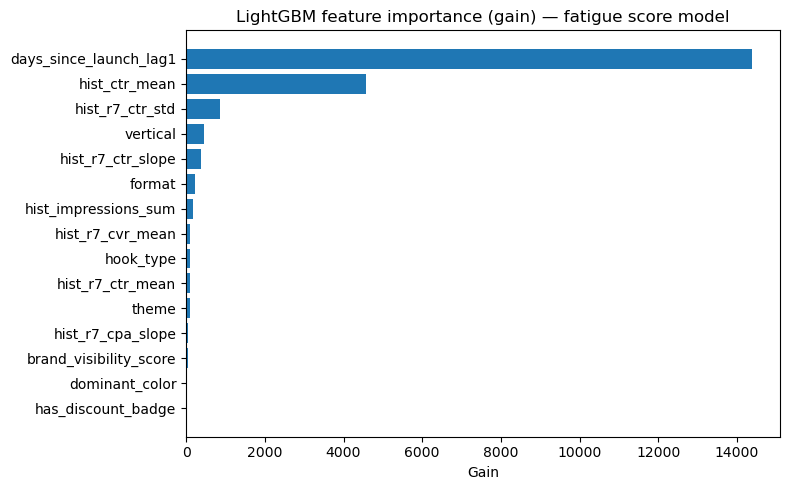

In [17]:
try:
    import matplotlib.pyplot as plt

    top = imp.head(15)
    plt.figure(figsize=(8, 5))
    plt.barh(top["feature"][::-1], top["importance_gain"][::-1])
    plt.title("LightGBM feature importance (gain) — fatigue score model")
    plt.xlabel("Gain")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Plot skipped:", e)

## 6) Optional: SHAP (install with `pip install shap`)

Tree SHAP explains **per-row** contributions — useful for “why is this creative fatiguing?” in a product UI later.

In [18]:
try:
    import shap

    sample = test.sample(n=min(2000, len(test)), random_state=RANDOM_SEED)
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(_as_category(sample[FEATURES]))
    shap.summary_plot(shap_values, _as_category(sample[FEATURES]), max_display=15, show=True)
except Exception as e:
    print("SHAP skipped:", e)

SHAP skipped: No module named 'shap'


## 7) Export scored rows for a future DB table / API

Each row is one **(creative_id, pred_date)** with **actual** vs **predicted** fatigue score for the **last-week** simulation.

In [19]:
export_cols = [
    "creative_id",
    "campaign_id",
    "pred_date",
    "y_fatigue_score",
    "pred_fatigue_score",
]
out_path = NOTEBOOK_DIR / "joel_fatigue_last_week_scored.parquet"
try:
    test[export_cols].to_parquet(out_path, index=False)
    print("wrote", out_path)
except Exception:
    csv_path = NOTEBOOK_DIR / "joel_fatigue_last_week_scored.csv"
    test[export_cols].to_csv(csv_path, index=False)
    print("parquet unavailable; wrote", csv_path)

wrote /Users/joelsanfeliu/Downloads/HACK_UPC_SMADEX/data_science/notebooks/joel_fatigue_last_week_scored.parquet


## Notes / next steps

- **This notebook intentionally avoids `creative_summary.csv` as a training label.** The synthetic `creative_status` / `fatigue_day` can still be used **offline** to sanity-check clusters of high `y_fatigue_score` vs labels.
- **If you add multi-horizon forecasting** (CTR/CPA paths), extend the label or train separate heads; keep the same **date leakage** discipline.
- For **Postgres**, materialize a table like `creative_fatigue_daily(creative_id, date, fatigue_score_actual, fatigue_score_pred, model_version, trained_until_date)` and serve it from FastAPI.